In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df = pd.read_csv(r"E:\archive (3)\critical_minerals_supply_master.csv")

In [3]:
df

,year,mineral,country,is_rare_earth,end_use,mine_production_tonnes,production_share_pct,reserves_tonnes,years_of_reserves,refined_share_pct,price_usd_per_tonne,demand_growth_pct,export_control_active,hhi,top_country_share_pct,supply_risk_score,high_supply_risk,disruption,disruption_next_year
0,2015,Antimony,Australia,0,flame_ret,5853.8,3.97,123696.0,21.1,3.18,11340.82,10.4,0,0.3796,57.75,28.2,0,0,0.0
1,2016,Antimony,Australia,0,flame_ret,6385.8,3.95,215205.0,33.7,3.16,11738.55,7.9,0,0.3549,52.35,29.1,0,0,0.0
2,2017,Antimony,Australia,0,flame_ret,6342.4,3.75,379889.0,59.9,3.00,10595.20,7.1,0,0.3604,52.93,23.3,0,0,0.0
3,2018,Antimony,Australia,0,flame_ret,7178.8,4.09,86793.0,12.1,3.27,11535.79,9.2,0,0.3784,58.15,41.5,0,0,0.0
4,2019,Antimony,Australia,0,flame_ret,6516.7,3.89,167755.0,25.7,3.11,11603.62,6.0,0,0.3880,57.97,28.9,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1543,2022,Yttrium,Myanmar,1,phosphor,1047.8,11.43,28737.0,27.4,9.14,73500.00,8.1,0,0.6199,77.52,57.6,1,0,0.0
1544,2023,Yttrium,Myanmar,1,phosphor,985.2,10.72,28452.0,28.9,8.58,49000.00,9.3,0,0.6169,73.79,59.1,1,0,0.0
1545,2024,Yttrium,Myanmar,1,phosphor,1098.5,11.04,24567.0,22.4,8.83,42000.00,4.7,0,0.6291,78.10,57.9,1,0,0.0
1546,2025,Yttrium,Myanmar,1,phosphor,1104.3,10.89,14871.0,13.5,8.71,56000.00,6.0,0,0.6381,81.93,63.2,1,0,0.0


In [4]:
X = df.drop('high_supply_risk', axis=1)
y = df['high_supply_risk']

In [5]:
X = pd.get_dummies(X, drop_first=True)

In [6]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train_scaled = pd.DataFrame(
    scaler.fit_transform(x_train),
    columns=x_train.columns,
    index=x_train.index
)

x_test_scaled = pd.DataFrame(
    scaler.transform(x_test),
    columns=x_test.columns,
    index=x_test.index
)

In [8]:
print(x_train_scaled.head())

          year  is_rare_earth  mine_production_tonnes  production_share_pct  \
680   0.718514      -0.565535               -0.278862              0.890873   
1079  1.582406      -0.565535               -0.297350             -0.313710   
1190 -1.009269      -0.565535               -0.297304             -0.381789   
864  -1.585197      -0.565535               -0.225247             -0.520927   
743   1.582406      -0.565535                1.778734             -0.561774   

      reserves_tonnes  years_of_reserves  refined_share_pct  \
680         -0.232278           1.614280           0.422034   
1079        -0.261551          -0.478146          -0.359507   
1190        -0.261528          -0.848956          -0.404018   
864         -0.178049           0.574689          -0.494077   
743          2.268516           0.720364          -0.520646   

      price_usd_per_tonne  demand_growth_pct  export_control_active  ...  \
680             -0.296748           2.519527              -0.134507  .

In [9]:
df.head()

,year,mineral,country,is_rare_earth,end_use,mine_production_tonnes,production_share_pct,reserves_tonnes,years_of_reserves,refined_share_pct,price_usd_per_tonne,demand_growth_pct,export_control_active,hhi,top_country_share_pct,supply_risk_score,high_supply_risk,disruption,disruption_next_year
0,2015,Antimony,Australia,0,flame_ret,5853.8,3.97,123696.0,21.1,3.18,11340.82,10.4,0,0.3796,57.75,28.2,0,0,0.0
1,2016,Antimony,Australia,0,flame_ret,6385.8,3.95,215205.0,33.7,3.16,11738.55,7.9,0,0.3549,52.35,29.1,0,0,0.0
2,2017,Antimony,Australia,0,flame_ret,6342.4,3.75,379889.0,59.9,3.00,10595.20,7.1,0,0.3604,52.93,23.3,0,0,0.0
3,2018,Antimony,Australia,0,flame_ret,7178.8,4.09,86793.0,12.1,3.27,11535.79,9.2,0,0.3784,58.15,41.5,0,0,0.0
4,2019,Antimony,Australia,0,flame_ret,6516.7,3.89,167755.0,25.7,3.11,11603.62,6.0,0,0.3880,57.97,28.9,0,0,0.0


In [10]:
df.describe()

,year,is_rare_earth,mine_production_tonnes,production_share_pct,reserves_tonnes,years_of_reserves,refined_share_pct,price_usd_per_tonne,demand_growth_pct,export_control_active,hhi,top_country_share_pct,supply_risk_score,high_supply_risk,disruption,disruption_next_year
count,1548.000000,1548.00000,1.548000e+03,1548.000000,1.548000e+03,1548.000000,1548.000000,1.548000e+03,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000,1548.000000,1419.000000
mean,2020.500000,0.24031,6.052152e+05,18.620433,1.976624e+07,34.150194,19.392720,2.668383e+06,11.009432,0.016150,0.431237,58.350362,37.669961,0.300388,0.045866,0.050035
std,3.453168,0.42741,1.987323e+06,23.165185,7.317379e+07,15.095650,28.706147,8.744352e+06,7.811259,0.126093,0.201094,19.916138,19.203015,0.458575,0.209261,0.218095
min,2015.000000,0.00000,4.600000e+00,0.950000,6.900000e+01,8.000000,0.760000,1.100000e+03,-4.200000,0.000000,0.165300,28.450000,0.000000,0.000000,0.000000,0.000000
25%,2017.750000,0.00000,4.132500e+02,5.227500,1.039400e+04,20.900000,4.240000,1.059520e+04,5.400000,0.000000,0.266800,37.820000,21.300000,0.000000,0.000000,0.000000
50%,2020.500000,0.00000,7.134300e+03,8.620000,2.145465e+05,34.500000,7.115000,3.152898e+04,8.600000,0.000000,0.420300,60.550000,36.600000,0.000000,0.000000,0.000000
75%,2023.250000,0.00000,9.526335e+04,16.247500,2.941683e+06,47.225000,15.522500,2.291356e+05,15.300000,0.000000,0.552800,74.170000,51.500000,1.000000,0.000000,0.000000
max,2026.000000,1.00000,2.457771e+07,100.110000,1.228059e+09,60.000000,100.000000,4.160496e+07,39.300000,1.000000,0.910100,100.110000,100.000000,1.000000,1.000000,1.000000


In [11]:
df=df.iloc[:,2:]

# Train test split

In [12]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(df.drop('high_supply_risk', axis=1),
                                                     df['high_supply_risk'],
                                                     test_size=0.3,
                                                     random_state=0)

x_train.shape, x_test.shape

((1083, 16), (465, 16))

# StandardScaler

In [13]:
print(x_train.head())

      country  is_rare_earth        end_use  mine_production_tonnes  \
464       USA              0  semiconductor                    11.0   
1239   Rwanda              0      capacitor                   376.4   
195    Russia              0        battery                  8858.8   
1537  Myanmar              1       phosphor                   778.9   
1225  Nigeria              0      capacitor                   117.4   

      production_share_pct  reserves_tonnes  years_of_reserves  \
464                   6.42            473.0               42.9   
1239                 28.10          15489.0               41.1   
195                   5.03         462755.0               52.2   
1537                 10.69          39678.0               50.9   
1225                  9.51           3179.0               27.1   

      refined_share_pct  price_usd_per_tonne  demand_growth_pct  \
464                5.13           1764407.78               10.1   
1239              22.48            194174.

In [14]:
import pandas as pd

df = pd.DataFrame(
    df,
    columns=df.columns,
    index=df.index
)

print(df.head())

     country  is_rare_earth    end_use  mine_production_tonnes  \
0  Australia              0  flame_ret                  5853.8   
1  Australia              0  flame_ret                  6385.8   
2  Australia              0  flame_ret                  6342.4   
3  Australia              0  flame_ret                  7178.8   
4  Australia              0  flame_ret                  6516.7   

   production_share_pct  reserves_tonnes  years_of_reserves  \
0                  3.97         123696.0               21.1   
1                  3.95         215205.0               33.7   
2                  3.75         379889.0               59.9   
3                  4.09          86793.0               12.1   
4                  3.89         167755.0               25.7   

   refined_share_pct  price_usd_per_tonne  demand_growth_pct  \
0               3.18             11340.82               10.4   
1               3.16             11738.55                7.9   
2               3.00            

In [15]:
numeric_df = df.select_dtypes(include=['number'])

print(numeric_df.head())

   is_rare_earth  mine_production_tonnes  production_share_pct  \
0              0                  5853.8                  3.97   
1              0                  6385.8                  3.95   
2              0                  6342.4                  3.75   
3              0                  7178.8                  4.09   
4              0                  6516.7                  3.89   

   reserves_tonnes  years_of_reserves  refined_share_pct  price_usd_per_tonne  \
0         123696.0               21.1               3.18             11340.82   
1         215205.0               33.7               3.16             11738.55   
2         379889.0               59.9               3.00             10595.20   
3          86793.0               12.1               3.27             11535.79   
4         167755.0               25.7               3.11             11603.62   

   demand_growth_pct  export_control_active     hhi  top_country_share_pct  \
0               10.4                  

In [16]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(numeric_df)

In [17]:
numeric_df

,is_rare_earth,mine_production_tonnes,production_share_pct,reserves_tonnes,years_of_reserves,refined_share_pct,price_usd_per_tonne,demand_growth_pct,export_control_active,hhi,top_country_share_pct,supply_risk_score,high_supply_risk,disruption,disruption_next_year
0,0,5853.8,3.97,123696.0,21.1,3.18,11340.82,10.4,0,0.3796,57.75,28.2,0,0,0.0
1,0,6385.8,3.95,215205.0,33.7,3.16,11738.55,7.9,0,0.3549,52.35,29.1,0,0,0.0
2,0,6342.4,3.75,379889.0,59.9,3.00,10595.20,7.1,0,0.3604,52.93,23.3,0,0,0.0
3,0,7178.8,4.09,86793.0,12.1,3.27,11535.79,9.2,0,0.3784,58.15,41.5,0,0,0.0
4,0,6516.7,3.89,167755.0,25.7,3.11,11603.62,6.0,0,0.3880,57.97,28.9,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1543,1,1047.8,11.43,28737.0,27.4,9.14,73500.00,8.1,0,0.6199,77.52,57.6,1,0,0.0
1544,1,985.2,10.72,28452.0,28.9,8.58,49000.00,9.3,0,0.6169,73.79,59.1,1,0,0.0
1545,1,1098.5,11.04,24567.0,22.4,8.83,42000.00,4.7,0,0.6291,78.10,57.9,1,0,0.0
1546,1,1104.3,10.89,14871.0,13.5,8.71,56000.00,6.0,0,0.6381,81.93,63.2,1,0,0.0


In [18]:
x_train

,country,is_rare_earth,end_use,mine_production_tonnes,production_share_pct,reserves_tonnes,years_of_reserves,refined_share_pct,price_usd_per_tonne,demand_growth_pct,export_control_active,hhi,top_country_share_pct,supply_risk_score,disruption,disruption_next_year
464,USA,0,semiconductor,11.0,6.42,473.0,42.9,5.13,1764407.78,10.1,0,0.6576,82.09,48.3,0,0.0
1239,Rwanda,0,capacitor,376.4,28.10,15489.0,41.1,22.48,194174.69,8.1,0,0.2668,37.81,15.3,0,0.0
195,Russia,0,battery,8858.8,5.03,462755.0,52.2,4.03,45000.00,30.4,0,0.4639,64.25,41.9,0,0.0
1537,Myanmar,1,phosphor,778.9,10.69,39678.0,50.9,8.55,31500.00,6.5,0,0.6456,80.15,60.0,0,0.0
1225,Nigeria,0,capacitor,117.4,9.51,3179.0,27.1,7.61,185641.74,9.2,0,0.2703,38.72,12.4,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
763,Gabon,0,battery,8252947.4,19.05,402460424.0,48.8,15.24,2244.31,18.4,0,0.2051,35.78,7.9,0,0.0
835,Myanmar,1,magnet,3132.9,5.82,119321.0,38.1,4.66,115500.00,20.7,0,0.4980,68.61,48.6,0,0.0
1216,DRC,0,capacitor,580.1,41.29,28405.0,49.0,33.03,219685.95,7.0,0,0.2750,41.29,24.0,0,0.0
559,China,0,display,610.5,56.38,30833.0,50.5,84.57,326743.76,3.3,0,0.3762,56.38,38.6,0,0.0


In [19]:
y_test

53      0
1166    0
1464    0
66      0
191     0
       ..
1128    1
1462    0
445     1
654     0
1470    0
Name: high_supply_risk, Length: 465, dtype: int64

In [20]:
x_test

,country,is_rare_earth,end_use,mine_production_tonnes,production_share_pct,reserves_tonnes,years_of_reserves,refined_share_pct,price_usd_per_tonne,demand_growth_pct,export_control_active,hhi,top_country_share_pct,supply_risk_score,disruption,disruption_next_year
53,Tajikistan,0,flame_ret,29053.3,15.69,940907.0,32.4,12.55,11562.73,6.9,0,0.3812,58.08,31.4,0,0.0
1166,USA,1,magnet,1415.5,9.14,81873.0,57.8,7.31,66000.00,19.1,0,0.5729,77.67,44.6,0,0.0
1464,China,0,alloy,37328.5,51.19,1840687.0,49.3,76.78,26125.26,4.1,0,0.3681,51.19,32.2,0,0.0
66,Australia,1,catalyst,8433.2,12.75,124130.0,14.7,10.20,4750.00,10.9,0,0.4413,63.03,44.8,1,0.0
191,Indonesia,0,battery,18288.5,3.68,186192.0,10.2,2.94,31500.00,27.7,0,0.5199,71.06,43.4,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1128,China,1,magnet,10262.3,78.06,603901.0,58.8,100.00,60000.00,15.3,0,0.5749,78.06,52.5,0,0.0
1462,Brazil,0,alloy,5720.2,4.91,234050.0,40.9,3.93,30386.27,7.0,0,0.3895,56.34,24.3,0,0.0
445,Russia,0,semiconductor,6.8,5.07,393.0,58.0,4.06,1306428.52,18.6,0,0.6472,79.33,58.0,0,0.0
654,USA,1,catalyst,7630.3,13.83,257305.0,33.7,11.07,4180.00,3.0,0,0.4579,66.19,35.1,1,0.0


In [21]:
y_train

464     1
1239    0
195     0
1537    1
1225    0
       ..
763     0
835     1
1216    0
559     0
684     0
Name: high_supply_risk, Length: 1083, dtype: int64

In [22]:
np.round(x_train.describe(),1)

,is_rare_earth,mine_production_tonnes,production_share_pct,reserves_tonnes,years_of_reserves,refined_share_pct,price_usd_per_tonne,demand_growth_pct,export_control_active,hhi,top_country_share_pct,supply_risk_score,disruption,disruption_next_year
count,1083.0,1083.0,1083.0,1.083000e+03,1083.0,1083.0,1083.0,1083.0,1083.0,1083.0,1083.0,1083.0,1083.0,992.0
mean,0.2,593688.5,18.3,2.049087e+07,33.8,19.1,2407068.2,11.0,0.0,0.4,58.3,37.8,0.0,0.1
std,0.4,1973511.0,22.9,7.859665e+07,14.9,28.4,8290560.8,7.9,0.1,0.2,20.0,19.3,0.2,0.2
min,0.0,4.6,1.0,7.300000e+01,8.0,0.8,1100.0,-4.2,0.0,0.2,28.4,1.8,0.0,0.0
25%,0.0,432.6,5.2,1.225900e+04,20.9,4.2,7966.7,5.2,0.0,0.2,37.8,21.4,0.0,0.0
50%,0.0,7160.5,8.6,2.205920e+05,33.8,7.1,31500.0,8.6,0.0,0.4,60.6,36.5,0.0,0.0
75%,0.0,96196.6,15.7,2.749022e+06,46.5,15.4,219686.0,15.7,0.0,0.5,73.9,51.6,0.0,0.0
max,1.0,24577711.6,100.1,1.228059e+09,60.0,100.0,41604960.0,39.3,1.0,0.9,100.1,100.0,1.0,1.0


In [23]:
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv(r"E:\archive (3)\critical_minerals_supply_master.csv")

# Select numeric columns
numeric_df = df.select_dtypes(include='number')

# Scale
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_df)

# Convert to DataFrame
scaled_df = pd.DataFrame(scaled_data, columns=numeric_df.columns)

print(scaled_df.head())

       year  is_rare_earth  mine_production_tonnes  production_share_pct  \
0 -1.593255      -0.562429               -0.301690             -0.632638   
1 -1.303572      -0.562429               -0.301422             -0.633501   
2 -1.013890      -0.562429               -0.301444             -0.642138   
3 -0.724207      -0.562429               -0.301023             -0.627456   
4 -0.434524      -0.562429               -0.301356             -0.636092   

   reserves_tonnes  years_of_reserves  refined_share_pct  price_usd_per_tonne  \
0        -0.268524          -0.864780          -0.564965            -0.303956   
1        -0.267273          -0.029832          -0.565662            -0.303911   
2        -0.265021           1.706328          -0.571237            -0.304042   
3        -0.269028          -1.461171          -0.561828            -0.303934   
4        -0.267921          -0.559958          -0.567404            -0.303926   

   demand_growth_pct  export_control_active       hhi  t

# Effect of sacling

In [24]:
print(df.columns.tolist())

['year', 'mineral', 'country', 'is_rare_earth', 'end_use', 'mine_production_tonnes', 'production_share_pct', 'reserves_tonnes', 'years_of_reserves', 'refined_share_pct', 'price_usd_per_tonne', 'demand_growth_pct', 'export_control_active', 'hhi', 'top_country_share_pct', 'supply_risk_score', 'high_supply_risk', 'disruption', 'disruption_next_year']


In [26]:
x_train.columns

Index(['country', 'is_rare_earth', 'end_use', 'mine_production_tonnes',
       'production_share_pct', 'reserves_tonnes', 'years_of_reserves',
       'refined_share_pct', 'price_usd_per_tonne', 'demand_growth_pct',
       'export_control_active', 'hhi', 'top_country_share_pct',
       'supply_risk_score', 'disruption', 'disruption_next_year'],
      dtype='object')

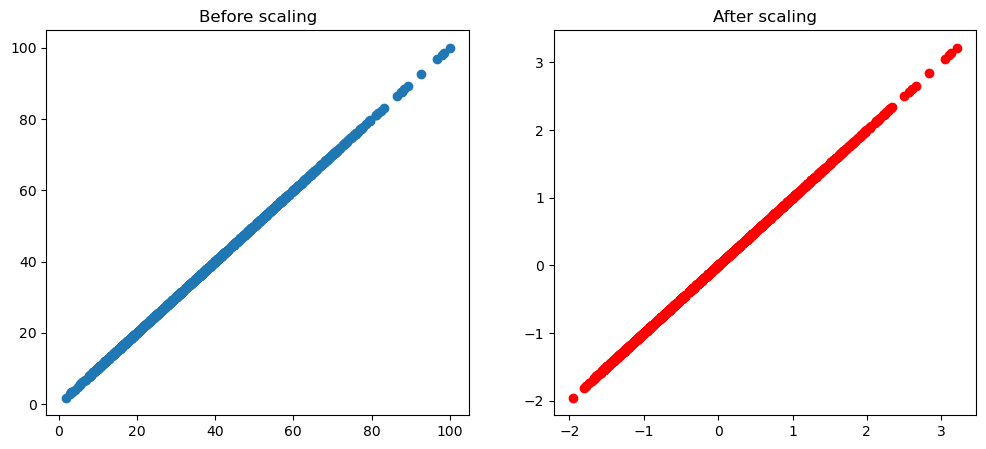

In [27]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(x_train['supply_risk_score'], x_train['supply_risk_score'])
ax1.set_title('Before scaling')
ax2.scatter(x_train_scaled['supply_risk_score'], x_train_scaled['supply_risk_score'], color='red')
ax2.set_title('After scaling')
plt.show()



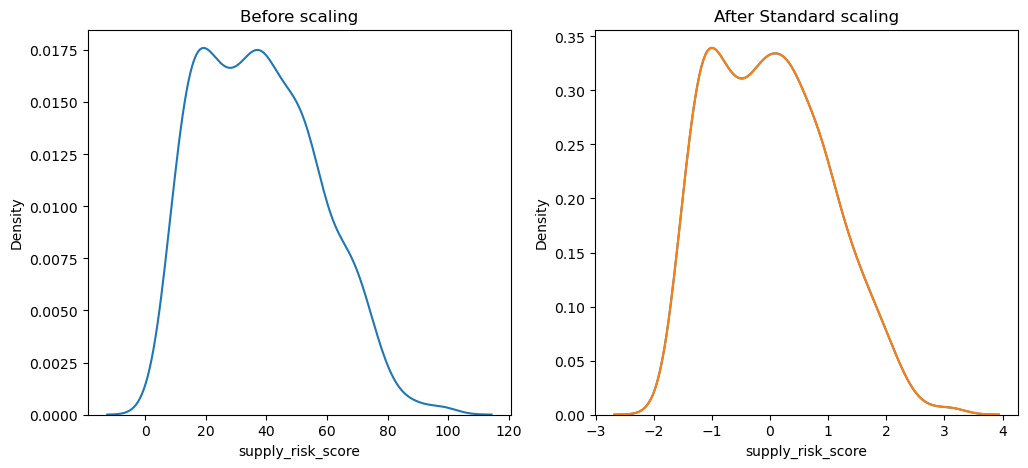

In [39]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12,5))
# before scaling
ax1.set_title('Before scaling')
sns.kdeplot(x_train['supply_risk_score'], ax = ax1)

# After scaling
ax2.set_title('After Standard scaling')
sns.kdeplot(x_train_scaled['supply_risk_score'], ax = ax2)
sns.kdeplot(x_train_scaled['supply_risk_score'], ax = ax2)
plt.show()

# comparison  of distributiom 

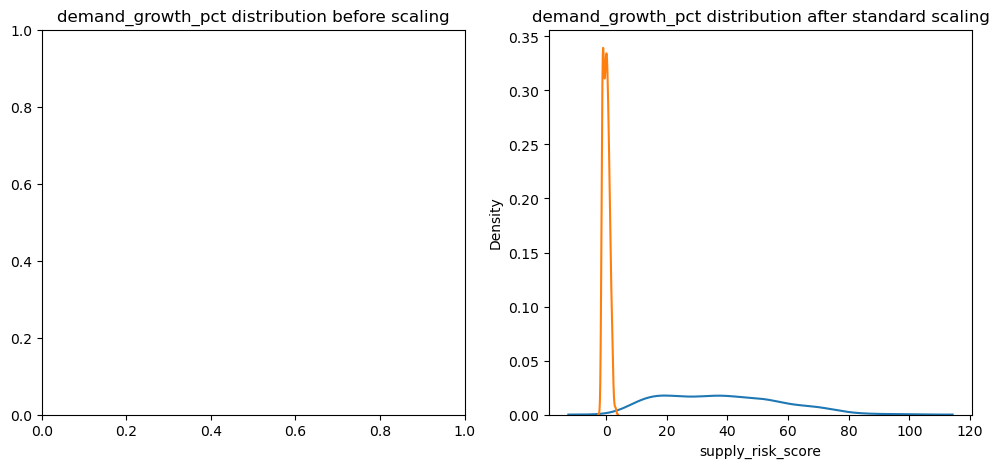

In [40]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('demand_growth_pct distribution before scaling')
sns.kdeplot(x_train['supply_risk_score'], ax=ax2)

# after scaling 
ax2.set_title('demand_growth_pct distribution after standard scaling')
sns.kdeplot(x_train_scaled['supply_risk_score'], ax=ax2)
plt.show()

# scaling

In [41]:
from sklearn.linear_model import LogisticRegression

In [45]:
from sklearn.linear_model import LogisticRegression

lr_scaled = LogisticRegression()

In [51]:
from sklearn.preprocessing import StandardScaler

# Keep only numeric columns
x_train_numeric = x_train.select_dtypes(include=['int64', 'float64'])

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train_numeric)

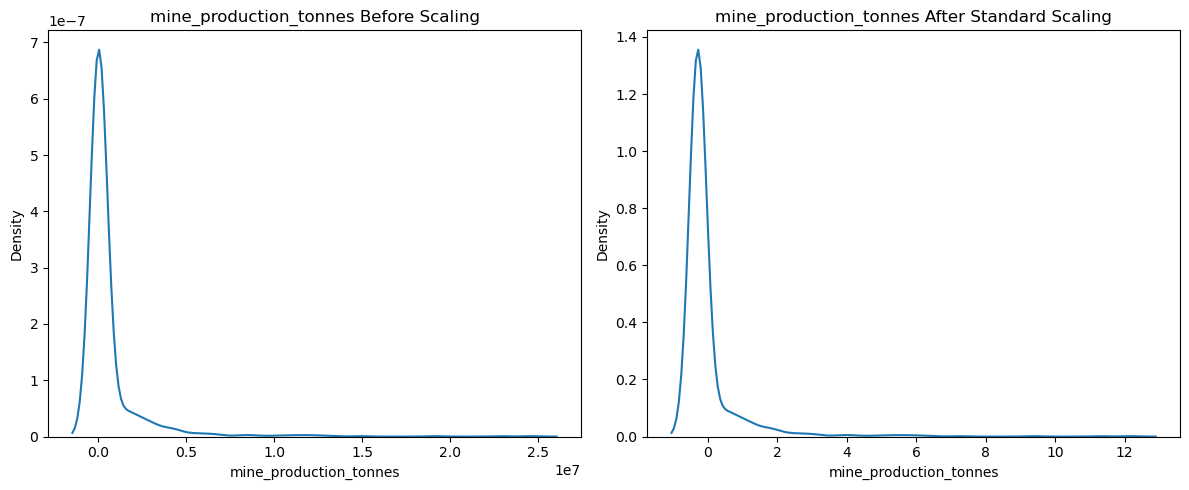

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Select only numeric columns
x_train_numeric = x_train.select_dtypes(include=['number'])

# Scale numeric columns
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train_numeric)

# Convert back to DataFrame
x_train_scaled = pd.DataFrame(
    x_train_scaled,
    columns=x_train_numeric.columns,
    index=x_train_numeric.index
)

# Choose the numeric column you want to visualize
column = "mine_production_tonnes"

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5))

# Before Scaling
ax1.set_title(f"{column} Before Scaling")
sns.kdeplot(data=x_train_numeric, x=column, ax=ax1)

# After Scaling
ax2.set_title(f"{column} After Standard Scaling")
sns.kdeplot(data=x_train_scaled, x=column, ax=ax2)

plt.tight_layout()
plt.show()